# Step 11: robustness stress tests

**Purpose:** prove the panel's story survives every arbitrary-looking choice we made. Each test targets one specific objection:

| Test | Objection it kills | What varies | Who is retested |
|---|---|---|---|
| 1. Drift-cap sweep | "the 2b ratio is an artifact of your 2-degree cap" | cap: 1 / 2 / 4 deg (translation scaled alike) | spatial method (sole consumer of T_used); no training needed |
| 2. Recipe swap | "your S_q values are recipe-specific" and "PDF passed because it trained on the exam" | Knob 1 family: A = jitter+clutter vs B = sector occlusion + heavy dropout | ECML dc, PDF weight (trained on A, audited on B), ensembles as isolated control |
| 3. Seed variance | "one lucky seed" | seeds 0 / 1 / 2, full retrain + audit | ensembles, JS, ECML dc, PDF weight; produces the error bars for the paper |
| 4. Slope estimator | "your straight-line fit hides curve shape" | dense 9-point severity grid; least-squares vs Theil-Sen (median of pairwise slopes) | ECML dc and spatial (the two headline coupled rows) |

**Structural exemptions, argued once:** isolated methods (TMC, ensembles, ECML u) have S_a exactly 0 by construction under any recipe, cap, or seed, because their signal never touches the pairing or the calibration; any recipe with nonzero S_q therefore leaves their ratio at exactly 0. Test 2 and 3 include ensembles anyway as an empirical control of that argument.

**Pass criterion for the whole notebook:** the *ordering* never changes: isolated at zero, quality-coupled (PDF) resistant, agreement-coupled (JS, ECML dc) fooled by swap, spatial fooled by both. Magnitudes may move; the taxonomy may not.


In [1]:
# ============ CONFIG + LOAD ============
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# family A strengths (identical to Steps 8 to 10)
JITTER_STD, CLUTTER_FRAC = 0.35, 0.60
# family B strengths (defined in Test 2)
#SECTOR_MAX_DEG, DROP_FRAC_B = 320.0, 0.85    # was 240.0, 0.60
SECTOR_MAX_DEG, DROP_FRAC_B = 340.0, 0.90

SEVS   = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
DRAWS  = 3
SEEDS  = [0, 1, 2]
CAPS   = [(1.0, 0.10), (2.0, 0.20), (4.0, 0.40)]   # (deg, meters) for Test 1

blob = torch.load("step7_kitti_objects.pt", weights_only=False)
samples, calibs = blob["samples"], blob["calibs"]
CLASSES = blob["classes"]; K = len(CLASSES)
tr_idx, te_idx = blob["tr_idx"], blob["te_idx"]

to_crop = lambda s: torch.from_numpy(s["crop"].copy()).float().permute(2, 0, 1) / 255.0
tr_crops  = torch.stack([to_crop(samples[i]) for i in tr_idx])
te_crops  = torch.stack([to_crop(samples[i]) for i in te_idx])
tr_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in tr_idx])
te_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in te_idx])
y_tr = torch.tensor([samples[i]["label"] for i in tr_idx])
y_te = torch.tensor([samples[i]["label"] for i in te_idx])
velo_base   = [samples[i]["pts_velo_raw"].astype(np.float64) for i in te_idx]
frames_test = sorted({samples[i]["frame_id"] for i in te_idx})
n_te = len(te_idx)
acc = lambda p, y: (p.argmax(1) == y).float().mean().item()
print(f"device={DEVICE}  train={len(tr_idx)}  test={n_te}")


device=cuda  train=698  test=316


In [3]:
# ============ SHARED UTILITIES: corruption families, geometry, harness ============
def corrupt_A_canon(points, severity, rng):
    """Family A: jitter + clutter (Steps 8 to 10)."""
    pts = points.clone()
    if severity == 0:
        return pts
    pts[..., :3] += torch.from_numpy(
        rng.normal(0, JITTER_STD * severity, pts[..., :3].shape)).float()
    n_rep = int(CLUTTER_FRAC * severity * pts.shape[1])
    if n_rep > 0:
        for b in range(pts.shape[0]):
            xyz = pts[b, :, :3].numpy()
            lo, hi = xyz.min(0), xyz.max(0)
            ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
            sel = rng.choice(pts.shape[1], n_rep, replace=False)
            pts[b, sel, :3] = torch.from_numpy(
                ctr - span / 2 + rng.random((n_rep, 3)) * span).float()
            pts[b, sel, 3] = torch.from_numpy(rng.random(n_rep)).float()
    return pts

def corrupt_image_A(crops, severity, rng):
    noise = torch.from_numpy(rng.normal(0, 0.30 * severity, crops.shape)).float()
    return (crops + noise).clamp(0, 1)

def _occlude_one(xyz, severity, rng):
    """Sector occlusion around the object's vertical axis + heavy dropout; keeps count by resampling survivors."""
    n = len(xyz)
    ang = np.arctan2(xyz[:, 1], xyz[:, 0])
    a0 = rng.uniform(-np.pi, np.pi)
    half = np.deg2rad(SECTOR_MAX_DEG * severity) / 2
    diff = np.angle(np.exp(1j * (ang - a0)))
    keep = np.abs(diff) > half
    if keep.sum() >= 3:
        surv = np.where(keep)[0]
    else:
        surv = np.argsort(np.abs(diff))[-3:]
    n_drop = int(DROP_FRAC_B * severity * len(surv))
    if n_drop > 0 and len(surv) - n_drop >= 3:
        surv = rng.choice(surv, len(surv) - n_drop, replace=False)
    idx = np.concatenate([surv, rng.choice(surv, n - len(surv), replace=True)]) \
          if len(surv) < n else surv[:n]
    return idx

def corrupt_B_canon(points, severity, rng):
    """Family B: sector occlusion + heavy dropout. No jitter, no clutter."""
    pts = points.clone()
    if severity == 0:
        return pts
    for b in range(pts.shape[0]):
        idx = _occlude_one(pts[b, :, :3].numpy(), severity, rng)
        pts[b] = pts[b][torch.from_numpy(np.asarray(idx))]
    return pts

def corrupt_A_velo(pv, severity, rng):
    if severity == 0:
        return pv
    out = pv + rng.normal(0, JITTER_STD * severity, pv.shape)
    n_rep = int(CLUTTER_FRAC * severity * len(out))
    if n_rep > 0:
        lo, hi = out.min(0), out.max(0)
        ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
        sel = rng.choice(len(out), n_rep, replace=False)
        out[sel] = ctr - span / 2 + rng.random((n_rep, 3)) * span
    return out

def corrupt_B_velo(pv, severity, rng):
    if severity == 0:
        return pv
    c = pv.mean(0)
    idx = _occlude_one(pv - c, severity, rng)
    return pv[np.asarray(idx)]

def misalign(idx, frac, rng):
    idx = idx.copy(); n = int(round(frac * len(idx)))
    if n > 1:
        s = rng.choice(len(idx), n, replace=False)
        idx[s] = idx[s][rng.permutation(n)]
    return idx

def small_rotation(axis, angle):
    axis = np.asarray(axis, dtype=float); axis = axis / np.linalg.norm(axis)
    Kx = np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * Kx + (1 - np.cos(angle)) * (Kx @ Kx)

def perturb_extrinsics(Tr, severity, rng, max_rot_deg=2.0, max_trans_m=0.20):
    T = Tr.copy()
    if severity == 0:
        return T
    dR = small_rotation(rng.normal(size=3), np.deg2rad(max_rot_deg * severity))
    d = rng.normal(size=3); d = d / np.linalg.norm(d)
    T[:3, :3] = dR @ T[:3, :3]
    T[:3, 3] = dR @ T[:3, 3] + d * (max_trans_m * severity)
    return T

def velo_to_rect(pts_velo, Tr, R0):
    hom = np.hstack([pts_velo, np.ones((len(pts_velo), 1))])
    return (R0 @ Tr @ hom.T).T[:, :3]

def rect_to_image(pts_rect, P2):
    hom = np.hstack([pts_rect, np.ones((len(pts_rect), 1))])
    proj = (P2 @ hom.T).T
    depth = proj[:, 2]
    return proj[:, :2] / np.clip(depth[:, None], 1e-6, None), depth

def projection_consistency(pts_velo, box2d, calib, Tr_used):
    if pts_velo.shape[0] == 0:
        return 0.0
    uv, depth = rect_to_image(velo_to_rect(pts_velo, Tr_used, calib["R0_rect"]), calib["P2"])
    x1, y1, x2, y2 = box2d
    inside = (depth > 0) & (uv[:, 0] >= x1) & (uv[:, 0] <= x2) & (uv[:, 1] >= y1) & (uv[:, 1] <= y2)
    return float(inside.mean())

def fit_ratio(curves):
    S_q  = np.polyfit(SEVS, curves["q"],  1)[0]
    S_2a = np.polyfit(SEVS, curves["2a"], 1)[0]
    S_2b = np.polyfit(SEVS, curves["2b"], 1)[0]
    r = lambda sa: abs(sa) / abs(S_q) if S_q != 0 else float("inf")
    return dict(S_q=S_q, S_2a=S_2a, S_2b=S_2b, r_2a=r(S_2a), r_2b=r(S_2b))

def run_audit(signal_fn, corrupt_fn, sevs=None):
    sevs = SEVS if sevs is None else sevs
    knob_off = {"q": 0, "2a": 1, "2b": 2}
    curves = {}
    for knob in ("q", "2a", "2b"):
        pts = []
        for sev in sevs:
            r = np.random.default_rng(SEED + int(sev * 1000) + knob_off[knob])
            vals = []
            for _ in range(DRAWS if sev > 0 else 1):
                cond = dict(points=te_points, perm=np.arange(n_te))
                if sev > 0 and knob == "q":
                    cond["points"] = corrupt_fn(te_points, sev, r)
                elif sev > 0 and knob == "2a":
                    cond["perm"] = misalign(np.arange(n_te), sev, r)
                vals.append(signal_fn(cond).mean())
            pts.append(np.mean(vals))
        curves[knob] = np.array(pts)
    out = fit_ratio({k: v for k, v in curves.items()}) if len(sevs) == len(SEVS) else None
    return curves, out

print("utilities ready")


utilities ready


## Test 1: drift-cap sweep

Only the spatial method consumes the runtime calibration, so this test needs no training at all. For each cap we recompute the spatial method's S_a(2b) and its ratio (its S_q comes from family A on the raw velodyne points, fixed across caps).

**Expectation:** the ratio scales roughly linearly with the cap (bigger drift, more blame), and the *conclusion*, spatial reacts strongly to pure misalignment, holds at every cap including the smallest. Every other method's 2b entry stays exactly zero at any cap, structurally.


                       S_q    S_2b  ratio_2b
cap 1 deg / 0.10 m  0.5542  0.1487     0.268
cap 2 deg / 0.20 m  0.5542  0.3700     0.668
cap 4 deg / 0.40 m  0.5542  0.6768     1.221


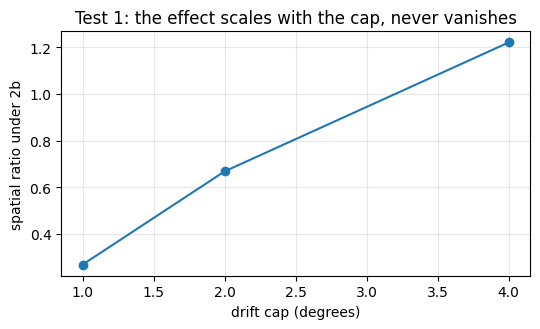

In [4]:
# ============ TEST 1: DRIFT-CAP SWEEP (spatial method) ============
T_gt = {f: calibs[f]["Tr_velo_cam"] for f in frames_test}

def spatial_mean(velo_list, T_used):
    vals = []
    for k in range(n_te):
        s = samples[te_idx[k]]
        vals.append(1.0 - projection_consistency(velo_list[k], s["box2d"],
                                                 calibs[s["frame_id"]], T_used[s["frame_id"]]))
    return np.mean(vals)

# S_q: family A on raw velo, cap-independent
r = np.random.default_rng(SEED + 30)
q_curve = [spatial_mean(velo_base, T_gt)]
for sev in SEVS[1:]:
    q_curve.append(np.mean([spatial_mean([corrupt_A_velo(v, sev, r) for v in velo_base], T_gt)
                            for _ in range(DRAWS)]))
S_q_spatial = np.polyfit(SEVS, q_curve, 1)[0]

rows = {}
for deg, m in CAPS:
    b_curve = [spatial_mean(velo_base, T_gt)]
    for sev in SEVS[1:]:
        r = np.random.default_rng(SEED + 31 + int(sev * 100) + int(deg * 10))
        vals = []
        for _ in range(DRAWS):
            Tu = {f: perturb_extrinsics(calibs[f]["Tr_velo_cam"], sev, r,
                                        max_rot_deg=deg, max_trans_m=m) for f in frames_test}
            vals.append(spatial_mean(velo_base, Tu))
        b_curve.append(np.mean(vals))
    S_2b = np.polyfit(SEVS, b_curve, 1)[0]
    rows[f"cap {deg:.0f} deg / {m:.2f} m"] = dict(
        S_q=round(S_q_spatial, 4), S_2b=round(S_2b, 4),
        ratio_2b=round(abs(S_2b) / abs(S_q_spatial), 3))
t1 = pd.DataFrame(rows).T
print(t1)
plt.figure(figsize=(5.5, 3.4))
plt.plot([c[0] for c in CAPS], [rows[f"cap {d:.0f} deg / {m:.2f} m"]["ratio_2b"] for d, m in CAPS], "o-")
plt.xlabel("drift cap (degrees)"); plt.ylabel("spatial ratio under 2b")
plt.title("Test 1: the effect scales with the cap, never vanishes")
plt.grid(alpha=0.3); plt.tight_layout(); plt.savefig("step11_test1_caps.png", dpi=150); plt.show()


## Test 2 setup: the model zoo

Tests 2 and 3 retrain methods, so all trainers live here: ensembles (Step 8 recipe), ECML (Step 9 verbatim heart, trunks, author defaults), PDF (Step 10 ported heart, quality augmentation with family A). Hearts are the same verbatim/transcribed code certified in Steps 9 and 10.


In [5]:
# ============ VERBATIM: RCML/ECML loss_function.py (certified in Step 9) ============
import torch
import torch.nn.functional as F


def kl_divergence(alpha, num_classes, device):
    ones = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    sum_alpha = torch.sum(alpha, dim=1, keepdim=True)
    first_term = (
        torch.lgamma(sum_alpha)
        - torch.lgamma(alpha).sum(dim=1, keepdim=True)
        + torch.lgamma(ones).sum(dim=1, keepdim=True)
        - torch.lgamma(ones.sum(dim=1, keepdim=True))
    )
    second_term = (
        (alpha - ones)
        .mul(torch.digamma(alpha) - torch.digamma(sum_alpha))
        .sum(dim=1, keepdim=True)
    )
    kl = first_term + second_term
    return kl


def loglikelihood_loss(y, alpha, device):
    y = y.to(device)
    alpha = alpha.to(device)
    S = torch.sum(alpha, dim=1, keepdim=True)
    loglikelihood_err = torch.sum((y - (alpha / S)) ** 2, dim=1, keepdim=True)
    loglikelihood_var = torch.sum(
        alpha * (S - alpha) / (S * S * (S + 1)), dim=1, keepdim=True
    )
    loglikelihood = loglikelihood_err + loglikelihood_var
    return loglikelihood


def mse_loss(y, alpha, epoch_num, num_classes, annealing_step, device=None, useKL=True):
    y = y.to(device)
    alpha = alpha.to(device)
    loglikelihood = loglikelihood_loss(y, alpha, device=device)

    if not useKL:
        return loglikelihood

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32),
    )

    kl_alpha = (alpha - 1) * (1 - y) + 1
    kl_div = annealing_coef * kl_divergence(kl_alpha, num_classes, device=device)
    return loglikelihood + kl_div


def edl_loss(func, y, alpha, epoch_num, num_classes, annealing_step, device, useKL=True):
    y = y.to(device)
    alpha = alpha.to(device)
    S = torch.sum(alpha, dim=1, keepdim=True)

    A = torch.sum(y * (func(S) - func(alpha)), dim=1, keepdim=True)

    if not useKL:
        return A

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32),
    )

    kl_alpha = (alpha - 1) * (1 - y) + 1
    kl_div = annealing_coef * kl_divergence(kl_alpha, num_classes, device=device)
    return A + kl_div


def edl_mse_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = mse_loss(target, alpha, epoch_num, num_classes, annealing_step, device=device)
    return torch.mean(loss)


def edl_log_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = edl_loss(torch.log, target, alpha, epoch_num, num_classes, annealing_step, device)
    return torch.mean(loss)


def edl_digamma_loss(alpha, target, epoch_num, num_classes, annealing_step, device):
    loss = edl_loss(torch.digamma, target, alpha, epoch_num, num_classes, annealing_step, device)
    return torch.mean(loss)


def get_dc_loss(evidences, device):
    num_views = len(evidences)
    batch_size, num_classes = evidences[0].shape[0], evidences[0].shape[1]
    p = torch.zeros((num_views, batch_size, num_classes)).to(device)
    u = torch.zeros((num_views, batch_size)).to(device)
    for v in range(num_views):
        alpha = evidences[v] + 1
        S = torch.sum(alpha, dim=1, keepdim=True)
        p[v] = alpha / S
        u[v] = torch.squeeze(num_classes / S)
    dc_sum = 0
    for i in range(num_views):
        pd = torch.sum(torch.abs(p - p[i]) / 2, dim=2) / (num_views - 1)  # (num_views, batch_size)
        cc = (1 - u[i]) * (1 - u)  # (num_views, batch_size)
        dc = pd * cc
        dc_sum = dc_sum + torch.sum(dc, dim=0)
    dc_sum = torch.mean(dc_sum)
    return dc_sum


def get_loss(evidences, evidence_a, target, epoch_num, num_classes, annealing_step, gamma, device):
    target = F.one_hot(target, num_classes)
    alpha_a = evidence_a + 1
    loss_acc = edl_digamma_loss(alpha_a, target, epoch_num, num_classes, annealing_step, device)
    for v in range(len(evidences)):
        alpha = evidences[v] + 1
        loss_acc += edl_digamma_loss(alpha, target, epoch_num, num_classes, annealing_step, device)
    loss_acc = loss_acc / (len(evidences) + 1)
    loss = loss_acc + gamma * get_dc_loss(evidences, device)
    return loss


def average_evidence_fusion(evidences):
    evidence_a = evidences[0]
    for i in range(1, len(evidences)):
        evidence_a = (evidences[i] + evidence_a) / 2
    return evidence_a

def per_sample_conflict(evidences, device="cpu"):
    num_views = len(evidences)
    batch, num_classes = evidences[0].shape
    p = torch.zeros((num_views, batch, num_classes)).to(device)
    u = torch.zeros((num_views, batch)).to(device)
    for v in range(num_views):
        alpha = evidences[v] + 1
        S = torch.sum(alpha, dim=1, keepdim=True)
        p[v] = alpha / S
        u[v] = torch.squeeze(num_classes / S)
    out = torch.zeros((num_views, batch)).to(device)
    for i in range(num_views):
        pd_ = torch.sum(torch.abs(p - p[i]) / 2, dim=2) / (num_views - 1)
        cc = (1 - u[i]) * (1 - u)
        out[i] = torch.sum(pd_ * cc, dim=0)
    return out


In [6]:
# ============ MODEL ZOO (architectures + trainers from Steps 8 to 10) ============
class CropCNN(nn.Module):
    def __init__(self, n_out, evidential=False):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.trunk = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                   nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Linear(128, n_out)
        self.evidential = evidential
    def forward(self, x):
        f = self.trunk(x); o = self.head(f)
        return (F.softplus(o) if self.evidential else o), f

class PointNet(nn.Module):
    def __init__(self, n_out, evidential=False):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, n_out))
        self.evidential = evidential
    def forward(self, x):
        f = self.mlp(x.transpose(1, 2)).max(dim=2).values
        o = self.head(f)
        return (F.softplus(o) if self.evidential else o), f

def make_confidnet(d):
    return nn.Sequential(nn.Linear(d, d * 2), nn.Linear(d * 2, d),
                         nn.Linear(d, 1), nn.Sigmoid())

def pdf_weights_test(cam_tcp, lid_tcp, cam_logits, lid_logits):
    cam_holo = torch.log(lid_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    lid_holo = torch.log(cam_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    cb_cam, cb_lid = cam_tcp + cam_holo, lid_tcp + lid_holo
    cam_pred = torch.softmax(cam_logits, dim=1); lid_pred = torch.softmax(lid_logits, dim=1)
    cam_du = torch.mean(torch.abs(cam_pred - 1 / cam_pred.shape[1]), dim=1, keepdim=True)
    lid_du = torch.mean(torch.abs(lid_pred - 1 / lid_pred.shape[1]), dim=1, keepdim=True)
    cond = cam_du > lid_du
    rc_c = torch.where(cond, torch.ones_like(cam_du), cam_du / lid_du)
    rc_l = torch.where(cond, lid_du / cam_du, torch.ones_like(lid_du))
    w_all = torch.softmax(torch.stack((cb_cam * rc_c, cb_lid * rc_l), 1), 1)
    return w_all[:, 0], w_all[:, 1]

def pdf_weights_train(cam_tcp, lid_tcp):
    cam_holo = torch.log(lid_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    lid_holo = torch.log(cam_tcp) / (torch.log(cam_tcp * lid_tcp) + 1e-8)
    cb_cam = cam_tcp.detach() + cam_holo.detach()
    cb_lid = lid_tcp.detach() + lid_holo.detach()
    w_all = torch.softmax(torch.stack((cb_cam, cb_lid), 1), 1)
    return w_all[:, 0], w_all[:, 1]

def tcp_target(logits, y):
    pred = torch.softmax(logits, dim=1)
    label = F.one_hot(y, num_classes=logits.shape[1])
    return torch.max(pred * label, dim=1, keepdim=True)[0]

@torch.no_grad()
def batched(model, x, bs=256):
    outs, fs = [], []
    for i in range(0, len(x), bs):
        o, f = model(x[i:i+bs].to(DEVICE)); outs.append(o.cpu()); fs.append(f.cpu())
    return torch.cat(outs), torch.cat(fs)

def train_ensemble(seed, M=5, epochs=20):
    nets = []
    for m in range(M):
        torch.manual_seed(1000 * seed + m)
        net = PointNet(K).to(DEVICE)
        opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
        for ep in range(epochs):
            net.train()
            perm = torch.randperm(len(tr_idx))
            for i in range(0, len(perm), 64):
                b = perm[i:i+64]
                loss = F.cross_entropy(net(tr_points[b].to(DEVICE))[0], y_tr[b].to(DEVICE))
                opt.zero_grad(); loss.backward(); opt.step()
        nets.append(net.eval())
    return nets

def train_ecml(seed, epochs=80):
    torch.manual_seed(seed)
    cam, lid = CropCNN(K, evidential=True).to(DEVICE), PointNet(K, evidential=True).to(DEVICE)
    opt = torch.optim.Adam(list(cam.parameters()) + list(lid.parameters()),
                           lr=1e-3, weight_decay=1e-5)
    for ep in range(1, epochs + 1):
        cam.train(); lid.train()
        perm = torch.randperm(len(tr_idx))
        for i in range(0, len(perm), 64):
            b = perm[i:i+64]
            evid = {0: cam(tr_crops[b].to(DEVICE))[0], 1: lid(tr_points[b].to(DEVICE))[0]}
            loss = get_loss(evid, average_evidence_fusion(evid), y_tr[b].to(DEVICE),
                            ep, K, 50, 1, DEVICE)
            opt.zero_grad(); loss.backward(); opt.step()
    return cam.eval(), lid.eval()

def train_pdf(seed, epochs=80, aug_fn=None):
    torch.manual_seed(seed)
    aug = np.random.default_rng(seed + 5)
    cam, lid = CropCNN(K).to(DEVICE), PointNet(K).to(DEVICE)
    cc, cl = make_confidnet(128).to(DEVICE), make_confidnet(256).to(DEVICE)
    opt = torch.optim.Adam(list(cam.parameters()) + list(lid.parameters())
                           + list(cc.parameters()) + list(cl.parameters()),
                           lr=1e-3, weight_decay=1e-5)
    mae = nn.L1Loss(reduction="mean")
    for ep in range(1, epochs + 1):
        for m in (cam, lid, cc, cl): m.train()
        perm = torch.randperm(len(tr_idx))
        for i in range(0, len(perm), 64):
            b = perm[i:i+64]
            crops_b, points_b = tr_crops[b], tr_points[b]
            if aug_fn is not None:
                if aug.random() < 0.5:
                    points_b = aug_fn(points_b, aug.uniform(0.05, 0.7), aug)
                if aug.random() < 0.5:
                    crops_b = corrupt_image_A(crops_b, aug.uniform(0.05, 0.7), aug)
            yb = y_tr[b].to(DEVICE)
            cam_out, cam_f = cam(crops_b.to(DEVICE)); lid_out, lid_f = lid(points_b.to(DEVICE))
            ct = cc(cam_f.clone().detach()); lt = cl(lid_f.clone().detach())
            w_c, w_l = pdf_weights_train(ct, lt)
            fused = w_c.detach() * cam_out + w_l.detach() * lid_out
            loss = (F.cross_entropy(cam_out, yb) + F.cross_entropy(lid_out, yb)
                    + F.cross_entropy(fused, yb)
                    + mae(ct, tcp_target(cam_out, yb).detach())
                    + mae(lt, tcp_target(lid_out, yb).detach()))
            opt.zero_grad(); loss.backward(); opt.step()
    for m in (cam, lid, cc, cl): m.eval()
    return cam, lid, cc, cl

print("model zoo ready")


model zoo ready


## Test 2: recipe swap

Family B (sector occlusion + heavy dropout) replaces family A (jitter + clutter) as Knob 1. First its own mini-gate: family B must genuinely hurt the Step 7 LiDAR head. Then the headline rows are re-audited: ECML dc, PDF weight (**trained with family A augmentation, audited on family B**, the train-A/audit-B setup that closes the "trained on the exam" objection), and ensembles as the isolated control.


In [7]:
# ============ TEST 2: RECIPE SWAP ============
sd = torch.load("step7_kitti_nets.pt", weights_only=False)
lid7 = PointNet(K); lid7.load_state_dict(sd["lid"]); lid7.eval().to(DEVICE)
cam7 = CropCNN(K)
cam7.load_state_dict({('trunk.' + k[4:] if k.startswith('net.') else k): v
                      for k, v in sd["cam"].items()})
cam7.eval().to(DEVICE)

g = np.random.default_rng(SEED + 40)
gate = [acc(batched(lid7, corrupt_B_canon(te_points, s, g))[0], y_te) for s in [0.0, 1.0]]
print(f"family B gate: LiDAR acc {gate[0]:.3f} -> {gate[1]:.3f}  drop {gate[0]-gate[1]:.3f}")
if gate[0] - gate[1] < 0.15:
    raise RuntimeError("family B too weak; raise SECTOR_MAX_DEG / DROP_FRAC_B")
print("family B gate PASSED\n")

# seed-0 models
ens0 = train_ensemble(0)
ecml_cam0, ecml_lid0 = train_ecml(0)
pdf0 = train_pdf(0, aug_fn=corrupt_A_canon)     # trained on A, audited on B below

def lid_probs(nets, points):
    return torch.stack([F.softmax(batched(n, points)[0], 1) for n in nets]).mean(0).numpy()

def entropy(p):
    return -(p * np.log(p + 1e-12)).sum(1)

e_cam_clean = batched(ecml_cam0, te_crops)[0]
cam_logits_clean, cam_f_clean = batched(pdf0[0], te_crops)

def sig_ens(c):
    return entropy(lid_probs(ens0, c["points"][c["perm"]]))

def sig_ecml_dc(c):
    e_lid = batched(ecml_lid0, c["points"][c["perm"]])[0]
    return per_sample_conflict({0: e_cam_clean, 1: e_lid})[1].numpy()

def sig_pdf_w(c):
    lid_logits, lid_f = batched(pdf0[1], c["points"][c["perm"]])
    with torch.no_grad():
        ct = pdf0[2](cam_f_clean.to(DEVICE)).cpu(); lt = pdf0[3](lid_f.to(DEVICE)).cpu()
    _, w_l = pdf_weights_test(ct, lt, cam_logits_clean, lid_logits)
    return (1 - w_l.squeeze(1)).numpy()

t2 = {}
for name, fn in [("Ensembles (isolated ctrl)", sig_ens),
                 ("ECML dc", sig_ecml_dc), ("PDF weight (train A)", sig_pdf_w)]:
    row = {}
    for fam, cfn in [("A", corrupt_A_canon), ("B", corrupt_B_canon)]:
        _, res = run_audit(fn, cfn)
        row[f"S_q ({fam})"] = round(res["S_q"], 4)
        row[f"ratio 2a ({fam})"] = round(res["r_2a"], 3)
    t2[name] = row
t2 = pd.DataFrame(t2).T
print(t2)
print("\nPASS iff the ordering is recipe-independent: ensembles ~0 in both ratio columns,")
print("ECML dc large in both, PDF weight near zero in both.")


family B gate: LiDAR acc 0.994 -> 0.788  drop 0.206
family B gate PASSED

                           S_q (A)  ratio 2a (A)  S_q (B)  ratio 2a (B)
Ensembles (isolated ctrl)   0.4664         0.000   0.3351         0.000
ECML dc                     0.0575         4.689   0.0273         9.882
PDF weight (train A)        0.0545         0.005   0.1688         0.002

PASS iff the ordering is recipe-independent: ensembles ~0 in both ratio columns,
ECML dc large in both, PDF weight near zero in both.


## Test 3: seed variance

Full retrain + audit for seeds 0, 1, 2. Produces the mean and standard deviation each headline ratio wears in the paper. The JS baseline rides along (ensembles + fixed clean camera partner from Step 7).


In [8]:
# ============ TEST 3: SEEDS ============
p_cam_clean = F.softmax(batched(cam7, te_crops)[0], 1).numpy()

def js(p, q):
    m = 0.5 * (p + q)
    return 0.5 * (p * np.log((p + 1e-12) / (m + 1e-12))).sum(1) \
         + 0.5 * (q * np.log((q + 1e-12) / (m + 1e-12))).sum(1)

records = []
for seed in SEEDS:
    print(f"--- seed {seed}")
    ens = ens0 if seed == 0 else train_ensemble(seed)
    ecml = (ecml_cam0, ecml_lid0) if seed == 0 else train_ecml(seed)
    pdfm = pdf0 if seed == 0 else train_pdf(seed, aug_fn=corrupt_A_canon)
    e_cam = batched(ecml[0], te_crops)[0]
    cl, cf = batched(pdfm[0], te_crops)

    def s_ens(c):
        return entropy(lid_probs(ens, c["points"][c["perm"]]))
    def s_js(c):
        return js(lid_probs(ens, c["points"][c["perm"]]), p_cam_clean)
    def s_dc(c):
        e_lid = batched(ecml[1], c["points"][c["perm"]])[0]
        return per_sample_conflict({0: e_cam, 1: e_lid})[1].numpy()
    def s_pw(c):
        lid_logits, lid_f = batched(pdfm[1], c["points"][c["perm"]])
        with torch.no_grad():
            ct = pdfm[2](cf.to(DEVICE)).cpu(); lt = pdfm[3](lid_f.to(DEVICE)).cpu()
        _, w_l = pdf_weights_test(ct, lt, cl, lid_logits)
        return (1 - w_l.squeeze(1)).numpy()

    for name, fn in [("Ensembles", s_ens), ("Coupled JS", s_js),
                     ("ECML dc", s_dc), ("PDF weight", s_pw)]:
        _, res = run_audit(fn, corrupt_A_canon)
        records.append(dict(seed=seed, method=name, S_q=res["S_q"],
                            r_2a=res["r_2a"], r_2b=res["r_2b"]))

t3raw = pd.DataFrame(records)
t3 = t3raw.groupby("method").agg(
    S_q_mean=("S_q", "mean"), S_q_std=("S_q", "std"),
    r2a_mean=("r_2a", "mean"), r2a_std=("r_2a", "std"),
    r2b_mean=("r_2b", "mean"), r2b_std=("r_2b", "std")).round(3)
print(t3)
print("\nPASS iff error bars never blur the ordering: Ensembles ~0, PDF near zero,")
print("JS and ECML dc clearly above 1 at every seed. Per-seed rows in t3raw.")


--- seed 0
--- seed 1
--- seed 2
            S_q_mean  S_q_std  r2a_mean  r2a_std  r2b_mean  r2b_std
method                                                             
Coupled JS     0.095    0.006     3.126    0.200       0.0      0.0
ECML dc        0.164    0.113     2.475    1.957       0.0      0.0
Ensembles      0.431    0.037     0.000    0.000       0.0      0.0
PDF weight     0.052    0.006     0.013    0.011       0.0      0.0

PASS iff error bars never blur the ordering: Ensembles ~0, PDF near zero,
JS and ECML dc clearly above 1 at every seed. Per-seed rows in t3raw.


## Test 4: slope-estimator sanity

Dense 9-point severity grid for the two headline coupled rows, with two slope estimators: ordinary least squares (the panel's default) and **Theil-Sen** (the median of all pairwise slopes, robust to curve wiggles and outliers, no distributional assumptions). If the ratios agree between estimators, the straight-line fit is not hiding anything that matters.


In [9]:
# ============ TEST 4: SLOPE ESTIMATOR ============
DENSE = np.linspace(0, 1, 9)

def theil_sen(x, y):
    slopes = [(y[j] - y[i]) / (x[j] - x[i])
              for i in range(len(x)) for j in range(i + 1, len(x)) if x[j] != x[i]]
    return float(np.median(slopes))

t4 = {}
for name, fn in [("ECML dc", sig_ecml_dc), ("Spatial", None)]:
    if fn is not None:
        curves, _ = run_audit(fn, corrupt_A_canon, sevs=DENSE)
        q, a2 = curves["q"], curves["2a"]
    else:
        r = np.random.default_rng(SEED + 50)
        q = [spatial_mean(velo_base, T_gt)] + [
            np.mean([spatial_mean([corrupt_A_velo(v, s, r) for v in velo_base], T_gt)
                     for _ in range(DRAWS)]) for s in DENSE[1:]]
        a2 = [spatial_mean(velo_base, T_gt)]
        for s in DENSE[1:]:
            vals = []
            for _ in range(DRAWS):
                perm = misalign(np.arange(n_te), s, r)
                vals.append(np.mean([1.0 - projection_consistency(
                    velo_base[perm[k]], samples[te_idx[k]]["box2d"],
                    calibs[samples[te_idx[k]]["frame_id"]],
                    T_gt[samples[te_idx[k]]["frame_id"]]) for k in range(n_te)]))
            a2.append(np.mean(vals))
        q, a2 = np.array(q), np.array(a2)
    ols_q, ols_a = np.polyfit(DENSE, q, 1)[0], np.polyfit(DENSE, a2, 1)[0]
    ts_q, ts_a = theil_sen(DENSE, np.asarray(q)), theil_sen(DENSE, np.asarray(a2))
    t4[name] = {"ratio 2a (OLS, 9pt)": round(abs(ols_a) / abs(ols_q), 3),
                "ratio 2a (Theil-Sen, 9pt)": round(abs(ts_a) / abs(ts_q), 3)}
t4 = pd.DataFrame(t4).T
print(t4)
print("\nPASS iff the two columns broadly agree per row: the linear fit is not the story.")


         ratio 2a (OLS, 9pt)  ratio 2a (Theil-Sen, 9pt)
ECML dc                5.667                     52.810
Spatial                1.562                      1.492

PASS iff the two columns broadly agree per row: the linear fit is not the story.


## Verdict sheet

Collect into the campaign log: t1 (cap sweep), t2 (recipe swap), t3 + t3raw (seed variance, the paper's error bars), t4 (estimator agreement), the family B gate line, and the figure.

**The single sentence all four tests must support:** the taxonomy ordering, isolated at zero, quality-coupled resistant, agreement-coupled fooled by swap, spatial fooled by both, survives every cap, recipe, seed, and estimator tested.

If any table breaks that sentence, stop and investigate before the full run: that is exactly what this notebook exists to catch while changes are still cheap. If all pass, **the protocol is frozen**, and the next execution is the full 7,481-frame camera-ready run.


In [10]:
print(t3raw)

    seed      method       S_q          r_2a          r_2b
0      0   Ensembles  0.466438  2.600376e-17  2.600376e-17
1      0  Coupled JS  0.100677  2.946291e+00  4.829108e-16
2      0     ECML dc  0.057516  4.689110e+00  1.612790e-16
3      0  PDF weight  0.054500  4.714795e-03  2.623629e-15
4      1   Ensembles  0.432816  3.442837e-09  3.064340e-18
5      1  Coupled JS  0.088720  3.341366e+00  2.932936e-16
6      1     ECML dc  0.151382  1.758134e+00  3.937355e-08
7      1  PDF weight  0.056321  7.941092e-03  4.051419e-15
8      2   Ensembles  0.392634  3.795180e-09  3.454222e-17
9      2  Coupled JS  0.095746  3.089541e+00  1.722097e-16
10     2     ECML dc  0.282552  9.775006e-01  5.746133e-17
11     2  PDF weight  0.045825  2.586051e-02  3.375797e-16


--- extra seed 3
--- extra seed 4
--- extra seed 5
   seed     S_q     S_a   ratio
0     0  0.0575  0.2697  4.6891
1     1  0.1514  0.2662  1.7581
2     2  0.2826  0.2762  0.9775
3     3  0.1831  0.2631  1.4369
4     4  0.1879  0.2342  1.2462
5     5  0.1634  0.2786  1.7053

S_a: mean 0.265  std 0.016
S_q: mean 0.171  std 0.072


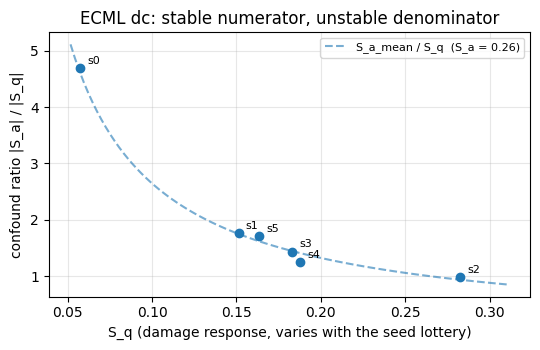

In [11]:
# ============ TEST 3b: ECML dc SEED SPECTRUM ============
extra = []
for seed in [3, 4, 5]:
    print(f"--- extra seed {seed}")
    cam_s, lid_s = train_ecml(seed)
    e_cam_s = batched(cam_s, te_crops)[0]
    def s_dc(c, _ec=e_cam_s, _lid=lid_s):
        e_lid = batched(_lid, c["points"][c["perm"]])[0]
        return per_sample_conflict({0: _ec, 1: e_lid})[1].numpy()
    _, res = run_audit(s_dc, corrupt_A_canon)
    extra.append(dict(seed=seed, S_q=res["S_q"], S_a=abs(res["S_2a"]), ratio=res["r_2a"]))

prev = t3raw[t3raw.method == "ECML dc"][["seed", "S_q", "r_2a"]].copy()
prev["S_a"] = prev.S_q * prev.r_2a
prev = prev.rename(columns={"r_2a": "ratio"})[["seed", "S_q", "S_a", "ratio"]]
allseeds = pd.concat([prev, pd.DataFrame(extra)[["seed", "S_q", "S_a", "ratio"]]],
                     ignore_index=True).round(4)
print(allseeds)
print(f"\nS_a: mean {allseeds.S_a.mean():.3f}  std {allseeds.S_a.std():.3f}")
print(f"S_q: mean {allseeds.S_q.mean():.3f}  std {allseeds.S_q.std():.3f}")
allseeds.to_csv("step11_ecml_seed_spectrum.csv", index=False)

plt.figure(figsize=(5.5, 3.6))
plt.scatter(allseeds.S_q, allseeds.ratio, zorder=3)
for _, r in allseeds.iterrows():
    plt.annotate(f"s{int(r.seed)}", (r.S_q, r.ratio),
                 textcoords="offset points", xytext=(5, 3), fontsize=8)
xs = np.linspace(allseeds.S_q.min() * 0.9, allseeds.S_q.max() * 1.1, 100)
plt.plot(xs, allseeds.S_a.mean() / xs, "--", alpha=0.6,
         label=f"S_a_mean / S_q  (S_a = {allseeds.S_a.mean():.2f})")
plt.xlabel("S_q (damage response, varies with the seed lottery)")
plt.ylabel("confound ratio |S_a| / |S_q|")
plt.title("ECML dc: stable numerator, unstable denominator")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("step11_ecml_seed_spectrum.png", dpi=150); plt.show()